# 🧠 Semana 7 — Modelos de Clasificación para el Análisis Diagnóstico
**Curso:** 92-0030 Diagnóstico y Predictibilidad  
**Profesor:** Robin Sequeira  
**Universidad:** ULACIT — I Cuatrimestre 2026  

---

### ¿Qué vamos a hacer hoy?

Hasta ahora predijimos **números** (regresión).  
Hoy predecimos **categorías**: ¿este tumor es **Maligno** o **Benigno**?

**Dataset:** Breast Cancer Wisconsin — 569 biopsias, 30 medidas celulares  
**Variable objetivo:** `diagnosis` → M (Maligno) o B (Benigno)

**Flujo del notebook:**
1. Cargar y explorar los datos
2. Seleccionar las variables más relevantes
3. Entrenar el modelo (Regresión Logística)
4. Evaluar: matriz de confusión, precisión, recall y F1
5. Interpretar los resultados en contexto médico

---
> ⚠️ **Antes de empezar:** subí el archivo `breast_cancer_semana7.csv` a Databricks desde  
> `Data → Add Data → Upload File` y copiá la ruta que te muestra.

## Celda 1 — Importar librerías

In [0]:
# ── Celda 1: Importar todas las librerías que vamos a usar ──────────────────
# Si alguna da error, avisale al profesor antes de continuar.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model    import LogisticRegression
from sklearn.preprocessing   import StandardScaler
from sklearn.pipeline        import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics         import (
    classification_report,
    ConfusionMatrixDisplay,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

print("✅ Todas las librerías cargaron correctamente.")
print(f"   pandas {pd.__version__}  |  numpy {np.__version__}")

✅ Todas las librerías cargaron correctamente.
   pandas 1.5.3  |  numpy 1.23.5


## Celda 2 — Cargar el dataset

In [0]:
# ── Celda 2: Cargar el CSV desde Databricks ─────────────────────────────────
#
# OPCIÓN A — Si subiste el CSV por la interfaz de Databricks:
#   Cambiá la ruta por la que te mostró Databricks al subir el archivo.
#   Ejemplo: /dbfs/FileStore/tables/breast_cancer_semana7.csv
#
# OPCIÓN B — Si usás Spark (modo Databricks nativo):
#   df = spark.read.csv("/FileStore/tables/breast_cancer_semana7.csv",
#                       header=True, inferSchema=True).toPandas()

RUTA_CSV = "workspace.diagnosticopredictibilidad.breast_cancer"  # ← Cambiá si es necesario


df = spark.table(RUTA_CSV).toPandas()

print("✅ Dataset cargado correctamente.")
print(f"   Filas:    {df.shape[0]}")
print(f"   Columnas: {df.shape[1]}")
print()
print("Distribución de la variable objetivo (diagnosis):")
print(df["diagnosis"].value_counts().to_string())
print()
vc = df["diagnosis"].value_counts()
pct_b = vc["B"] / len(df) * 100
pct_m = vc["M"] / len(df) * 100
print(f"   Benignos:  {vc['B']} ({pct_b:.1f}%)")
print(f"   Malignos:  {vc['M']} ({pct_m:.1f}%)")
print()
# INTERPRETACIÓN:
# Hay más tumores benignos que malignos (~63% vs ~37%).
# Este leve desbalance justifica usar F1-score además de accuracy.
print("💬 Hay un leve desbalance de clases.")
print("   Por eso vamos a reportar F1, precisión y recall, no solo accuracy.")

✅ Dataset cargado correctamente.
   Filas:    569
   Columnas: 31

Distribución de la variable objetivo (diagnosis):
B    357
M    212

   Benignos:  357 (62.7%)
   Malignos:  212 (37.3%)

💬 Hay un leve desbalance de clases.
   Por eso vamos a reportar F1, precisión y recall, no solo accuracy.


## Celda 3 — Exploración inicial

In [0]:
# ── Celda 3: Exploración inicial del dataset ────────────────────────────────
# Antes de modelar siempre miramos los datos: tipos, nulos y estadísticas.

print("═" * 55)
print("PRIMERAS 5 FILAS")
print("═" * 55)
display(df.head())

═══════════════════════════════════════════════════════
PRIMERAS 5 FILAS
═══════════════════════════════════════════════════════


mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
17.99,10.38,122.8,1001.0,0.1184,0.2776,0.3001,0.1471,0.2419,0.07871,1.095,0.9053,8.589,153.4,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189,M
20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.0186,0.0134,0.01389,0.003532,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.186,0.275,0.08902,M
19.69,21.25,130.0,1203.0,0.1096,0.1599,0.1974,0.1279,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.00615,0.04006,0.03832,0.02058,0.0225,0.004571,23.57,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.243,0.3613,0.08758,M
11.42,20.38,77.58,386.1,0.1425,0.2839,0.2414,0.1052,0.2597,0.09744,0.4956,1.156,3.445,27.23,0.00911,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.5,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.173,M
20.29,14.34,135.1,1297.0,0.1003,0.1328,0.198,0.1043,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.01149,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.2,1575.0,0.1374,0.205,0.4,0.1625,0.2364,0.07678,M


In [0]:
# Verificar si hay valores nulos
nulos = df.isnull().sum().sum()
print(f"Valores nulos en el dataset: {nulos}")

if nulos == 0:
    print("✅ El dataset está limpio, sin valores faltantes.")
else:
    print("⚠️ Hay nulos. Revisar antes de continuar.")
    print(df.isnull().sum()[df.isnull().sum() > 0])

print()
print("Tipos de datos (primeras columnas):")
print(df.dtypes.head(8).to_string())

Valores nulos en el dataset: 0
✅ El dataset está limpio, sin valores faltantes.

Tipos de datos (primeras columnas):
mean radius            float64
mean texture           float64
mean perimeter         float64
mean area              float64
mean smoothness        float64
mean compactness       float64
mean concavity         float64
mean concave points    float64


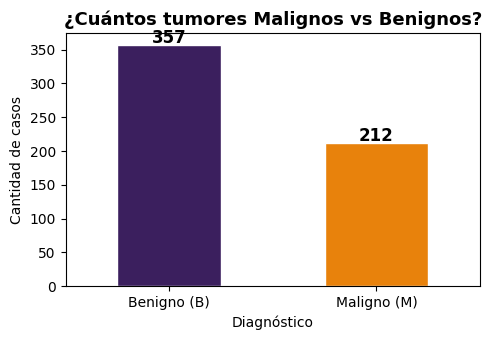


📌 INTERPRETACIÓN:
   El 62.7% de los tumores son benignos y el 37.3% son malignos.
   Un modelo que SIEMPRE prediga 'benigno' tendría 62.7% de accuracy...
   ...pero no detectaría NINGÚN tumor maligno. Por eso F1-score importa más.


In [0]:
# Gráfico: distribución de la variable objetivo
fig, ax = plt.subplots(figsize=(5, 3.5))

colores = {"B": "#3B1F5E", "M": "#E8820C"}
vc = df["diagnosis"].value_counts()
vc.plot(kind="bar", color=[colores[k] for k in vc.index],
        ax=ax, edgecolor="white", width=0.5)

ax.set_title("¿Cuántos tumores Malignos vs Benignos?", fontsize=13, fontweight="bold")
ax.set_xlabel("Diagnóstico")
ax.set_ylabel("Cantidad de casos")
ax.set_xticklabels(["Benigno (B)", "Maligno (M)"], rotation=0)

# Agregar etiquetas encima de cada barra
for p in ax.patches:
    ax.annotate(str(int(p.get_height())),
                (p.get_x() + p.get_width() / 2, p.get_height() + 3),
                ha="center", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

print("\n📌 INTERPRETACIÓN:")
print(f"   El 62.7% de los tumores son benignos y el 37.3% son malignos.")
print("   Un modelo que SIEMPRE prediga 'benigno' tendría 62.7% de accuracy...")
print("   ...pero no detectaría NINGÚN tumor maligno. Por eso F1-score importa más.")

## Celda 4 — Selección de variables por correlación

In [0]:
# ── Celda 4: ¿Qué variables tienen más relación con el diagnóstico? ──────────
#
# Para calcular correlaciones necesitamos que diagnosis sea numérico.
# Convertimos M=1 (Maligno) y B=0 (Benigno).
# Luego medimos cuánto se relaciona cada variable con ese 0/1.
# Solo nos quedamos con las que tengan correlación absoluta > 0.2.

df["diagnosis_num"] = (df["diagnosis"] == "M").astype(int)

# Columnas de features (todo menos diagnosis y diagnosis_num)
feat_cols = [c for c in df.columns if c not in ["diagnosis", "diagnosis_num"]]

# Correlación absoluta de cada variable con el diagnóstico
correlaciones = (
    df[feat_cols]
    .corrwith(df["diagnosis_num"])
    .abs()
    .sort_values(ascending=False)
)

print("TOP 10 variables más correlacionadas con el diagnóstico:")
print(correlaciones.head(10).round(3).to_string())

# Seleccionar solo las que superan el umbral
UMBRAL = 0.2
features_seleccionadas = correlaciones[correlaciones > UMBRAL].index.tolist()

print(f"\n✅ Variables seleccionadas (|correlación| > {UMBRAL}): {len(features_seleccionadas)} de {len(feat_cols)}")
print(features_seleccionadas)

TOP 10 variables más correlacionadas con el diagnóstico:
worst concave points    0.794
worst perimeter         0.783
mean concave points     0.777
worst radius            0.776
mean perimeter          0.743
worst area              0.734
mean radius             0.730
mean area               0.709
mean concavity          0.696
worst concavity         0.660

✅ Variables seleccionadas (|correlación| > 0.2): 25 de 30
['worst concave points', 'worst perimeter', 'mean concave points', 'worst radius', 'mean perimeter', 'worst area', 'mean radius', 'mean area', 'mean concavity', 'worst concavity', 'mean compactness', 'worst compactness', 'radius error', 'perimeter error', 'area error', 'worst texture', 'worst smoothness', 'worst symmetry', 'mean texture', 'concave points error', 'mean smoothness', 'mean symmetry', 'worst fractal dimension', 'compactness error', 'concavity error']


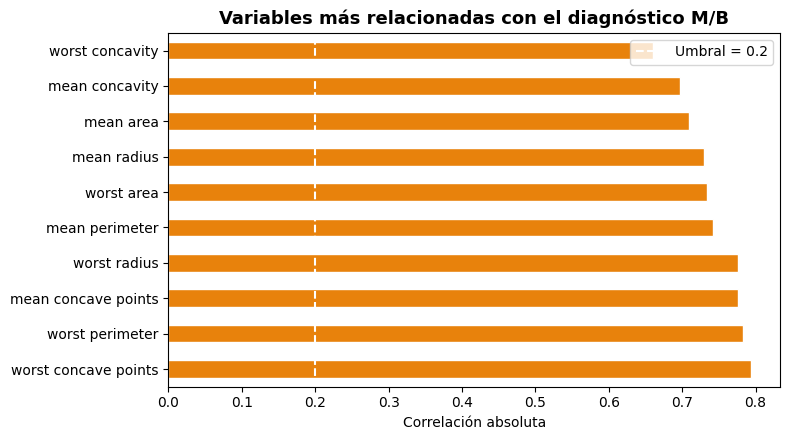


📌 INTERPRETACIÓN:
   Las variables con el nombre 'worst' (peor valor) y 'mean' (promedio)
   son las que más predicen si un tumor es maligno.
   Tiene sentido médico: el tamaño y la irregularidad del núcleo celular
   son señales clave de malignidad.


In [0]:
# Gráfico: Top 10 variables por correlación
fig, ax = plt.subplots(figsize=(8, 4.5))

top10 = correlaciones.head(10)
colores_barras = ["#E8820C" if v > UMBRAL else "#555" for v in top10.values]

top10.plot(kind="barh", color=colores_barras, ax=ax, edgecolor="white")

ax.axvline(UMBRAL, color="white", linestyle="--", linewidth=1.5,
           label=f"Umbral = {UMBRAL}")
ax.set_title("Variables más relacionadas con el diagnóstico M/B",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Correlación absoluta")
ax.legend()
plt.tight_layout()
plt.show()

print("\n📌 INTERPRETACIÓN:")
print("   Las variables con el nombre 'worst' (peor valor) y 'mean' (promedio)")
print("   son las que más predicen si un tumor es maligno.")
print("   Tiene sentido médico: el tamaño y la irregularidad del núcleo celular")
print("   son señales clave de malignidad.")

## Celda 5 — Preparar datos y dividir en entrenamiento/prueba

In [0]:
# ── Celda 5: Separar X (variables) e y (objetivo) ───────────────────────────

X = df[features_seleccionadas]   # Solo las variables seleccionadas
y = df["diagnosis_num"]          # 1=Maligno, 0=Benigno

# Dividir: 80% para entrenar, 20% para evaluar
# stratify=y asegura que la proporción M/B sea igual en train y test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,    # Semilla para reproducibilidad
    stratify=y          # Mantiene la proporción de clases
)

print("División del dataset:")
print(f"   Entrenamiento: {X_train.shape[0]} casos ({X_train.shape[0]/len(df)*100:.0f}%)")
print(f"   Prueba:        {X_test.shape[0]} casos  ({X_test.shape[0]/len(df)*100:.0f}%)")
print()
print("Distribución en el conjunto de prueba:")
print(f"   Benignos:  {(y_test==0).sum()}")
print(f"   Malignos:  {(y_test==1).sum()}")
print()
print("✅ División correcta. Las proporciones se mantienen en ambos conjuntos.")

División del dataset:
   Entrenamiento: 455 casos (80%)
   Prueba:        114 casos  (20%)

Distribución en el conjunto de prueba:
   Benignos:  72
   Malignos:  42

✅ División correcta. Las proporciones se mantienen en ambos conjuntos.


## Celda 6 — Construir y entrenar el modelo (Pipeline)

In [0]:
# ── Celda 6: Pipeline con StandardScaler + Regresión Logística ──────────────
#
# ¿Por qué un Pipeline?
#   Para que el escalado y el modelo se apliquen juntos de forma ordenada.
#   Evita errores de aplicar el scaler por separado.
#
# ¿Por qué StandardScaler?
#   La regresión logística es sensible a las escalas.
#   Algunas variables tienen valores en el rango 0-1 y otras llegan a 2000+.
#   StandardScaler las lleva todas a media=0 y desviación estándar=1.
#
# ¿Por qué max_iter=1000?
#   El optimizador necesita suficientes iteraciones para converger.
#   Con 100 (el default) a veces no alcanza.

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("modelo", LogisticRegression(max_iter=1000, random_state=42))
])

# Entrenar: el modelo aprende los patrones del 80% de los datos
pipeline.fit(X_train, y_train)

# Predecir sobre el 20% que el modelo nunca vio
y_pred = pipeline.predict(X_test)

print("✅ Modelo entrenado y predicciones generadas.")
print(f"   Variables usadas: {X_train.shape[1]}")
print(f"   Casos de prueba:  {X_test.shape[0]}")

✅ Modelo entrenado y predicciones generadas.
   Variables usadas: 25
   Casos de prueba:  114


## Celda 7 — Evaluación: Reporte de clasificación

In [0]:
# ── Celda 7: classification_report ──────────────────────────────────────────
#
# Este reporte muestra para CADA clase (Benigno y Maligno):
#
#  precision → de lo que dije que era maligno, ¿cuánto SÍ lo era?
#  recall    → de todos los malignos reales, ¿cuántos detecté?
#  f1-score  → balance entre precision y recall (0=pésimo, 1=perfecto)
#  support   → cuántos casos reales hay de esa clase

print("═" * 55)

print("REPORTE DE CLASIFICACIÓN — Breast Cancer")

print("═" * 55)

print(classification_report(

    y_test, y_pred,

    target_names=["Benigno (0)", "Maligno (1)"]

))

═══════════════════════════════════════════════════════
REPORTE DE CLASIFICACIÓN — Breast Cancer
═══════════════════════════════════════════════════════
              precision    recall  f1-score   support

 Benigno (0)       0.97      0.99      0.98        72
 Maligno (1)       0.98      0.95      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [0]:
# Interpretación automática del reporte
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)       # Para la clase Maligno (1)
rec  = recall_score(y_test, y_pred)           # Para la clase Maligno (1)
f1   = f1_score(y_test, y_pred)               # Para la clase Maligno (1)

print("📌 INTERPRETACIÓN DE LAS MÉTRICAS:")
print()
print(f"  Accuracy:  {acc*100:.1f}%")
print(f"  → El modelo acierta en el {acc*100:.1f}% de los casos.")
print()
print(f"  Precisión (Maligno): {prec*100:.1f}%")
print(f"  → De cada 100 veces que el modelo dice 'maligno',")
print(f"    {prec*100:.0f} realmente lo son.")
print()
print(f"  Recall (Maligno): {rec*100:.1f}%")
print(f"  → De cada 100 tumores malignos reales,")
print(f"    el modelo detecta {rec*100:.0f}.")
print(f"    Los {100-rec*100:.0f} restantes son Falsos Negativos (no detectados).")
print()
print(f"  F1-Score (Maligno): {f1:.3f}")
print(f"  → Balance entre precisión y recall. Cercano a 1.0 = muy bueno.")
print()
if rec >= 0.95:
    print("  ✅ Recall alto: el modelo detecta casi todos los malignos.")
elif rec >= 0.90:
    print("  ⚠️ Recall aceptable, pero considerar bajar el umbral de decisión.")
else:
    print("  ❌ Recall bajo: el modelo deja escapar muchos malignos reales.")

📌 INTERPRETACIÓN DE LAS MÉTRICAS:

  Accuracy:  97.4%
  → El modelo acierta en el 97.4% de los casos.

  Precisión (Maligno): 97.6%
  → De cada 100 veces que el modelo dice 'maligno',
    98 realmente lo son.

  Recall (Maligno): 95.2%
  → De cada 100 tumores malignos reales,
    el modelo detecta 95.
    Los 5 restantes son Falsos Negativos (no detectados).

  F1-Score (Maligno): 0.964
  → Balance entre precisión y recall. Cercano a 1.0 = muy bueno.

  ✅ Recall alto: el modelo detecta casi todos los malignos.


## Celda 8 — Matriz de confusión

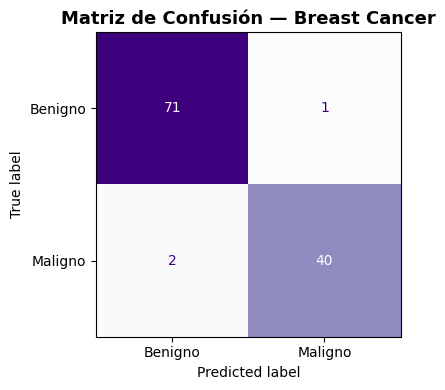

In [0]:
# ── Celda 8: Matriz de confusión visual ─────────────────────────────────────
#
# La matriz muestra los 4 tipos de resultados posibles:
#
#   TN (arriba izq): dijo Benigno  → era Benigno   ✅ correcto
#   FP (arriba der): dijo Maligno  → era Benigno   ⚠️ alarma falsa
#   FN (abajo izq):  dijo Benigno  → era Maligno   ❌ PELIGROSO
#   TP (abajo der):  dijo Maligno  → era Maligno   ✅ correcto

fig, ax = plt.subplots(figsize=(5, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["Benigno", "Maligno"],
    colorbar=False,
    cmap="Purples",
    ax=ax
)

ax.set_title("Matriz de Confusión — Breast Cancer",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [0]:
# Desglose numérico de la matriz
cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()

print("═" * 60)
print("DESGLOSE DE LA MATRIZ DE CONFUSIÓN")
print("═" * 60)
print(f"  TN — Verdadero Negativo:  {TN:3d}   Dijo Benigno  | Era Benigno   ✅")
print(f"  FP — Falso Positivo:      {FP:3d}   Dijo Maligno  | Era Benigno   ⚠️")
print(f"  FN — Falso Negativo:      {FN:3d}   Dijo Benigno  | Era Maligno   ❌")
print(f"  TP — Verdadero Positivo:  {TP:3d}   Dijo Maligno  | Era Maligno   ✅")
print()
print("📌 INTERPRETACIÓN:")
print()
print(f"  Los {FN} Falsos Negativos son el error más grave en medicina.")
print(f"  Son pacientes a quienes el modelo les diría 'todo está bien'")
print(f"  cuando en realidad tienen un tumor maligno.")
print()
print(f"  Los {FP} Falsos Positivos son una alarma falsa.")
print(f"  Son molestos e implican estudios extra, pero no son peligrosos.")
print()
total_real_malignos = FN + TP
print(f"  En resumen: de {total_real_malignos} tumores malignos reales,")
print(f"  el modelo detectó {TP} ({TP/total_real_malignos*100:.1f}%) y se le escaparon {FN} ({FN/total_real_malignos*100:.1f}%).")

════════════════════════════════════════════════════════════
DESGLOSE DE LA MATRIZ DE CONFUSIÓN
════════════════════════════════════════════════════════════
  TN — Verdadero Negativo:   71   Dijo Benigno  | Era Benigno   ✅
  FP — Falso Positivo:        1   Dijo Maligno  | Era Benigno   ⚠️
  FN — Falso Negativo:        2   Dijo Benigno  | Era Maligno   ❌
  TP — Verdadero Positivo:   40   Dijo Maligno  | Era Maligno   ✅

📌 INTERPRETACIÓN:

  Los 2 Falsos Negativos son el error más grave en medicina.
  Son pacientes a quienes el modelo les diría 'todo está bien'
  cuando en realidad tienen un tumor maligno.

  Los 1 Falsos Positivos son una alarma falsa.
  Son molestos e implican estudios extra, pero no son peligrosos.

  En resumen: de 42 tumores malignos reales,
  el modelo detectó 40 (95.2%) y se le escaparon 2 (4.8%).


## Celda 9 — Distribución de probabilidades predichas

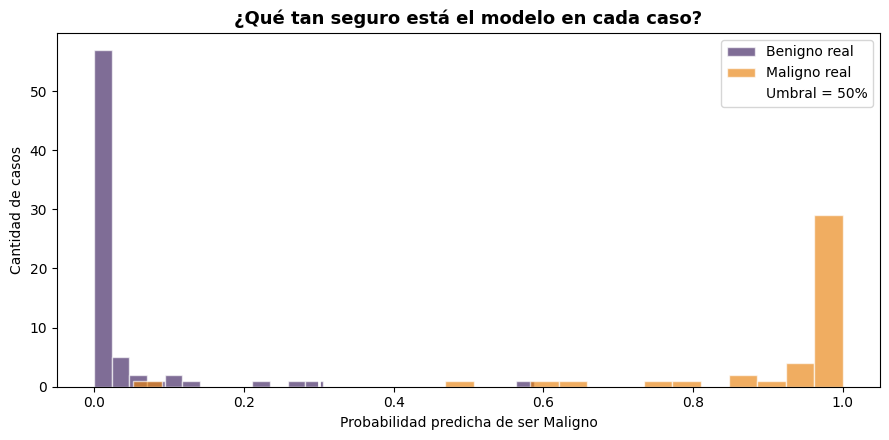

📌 INTERPRETACIÓN:
   Si las dos barras están bien separadas (morado cerca del 0,
   naranja cerca del 1), el modelo distingue bien entre clases.
   Si se solapan mucho cerca del 50%, hay casos dudosos
   donde el modelo no tiene certeza. En medicina, esos casos
   deberían enviarse a revisión adicional.


In [0]:
# ── Celda 9: ¿Qué tan seguro está el modelo en cada predicción? ─────────────
#
# predict_proba devuelve la probabilidad de cada clase.
# Tomamos la columna [:, 1] = probabilidad de ser Maligno.
#
# Un buen modelo debería:
#   - Agrupar los benignos cerca de 0%
#   - Agrupar los malignos cerca de 100%
# Si se mezclan cerca del 50%, el modelo tiene incertidumbre en esa zona.

probabilidades_maligno = pipeline.predict_proba(X_test)[:, 1]

fig, ax = plt.subplots(figsize=(9, 4.5))

# Benignos reales
ax.hist(probabilidades_maligno[y_test == 0], bins=25,
        alpha=0.65, color="#3B1F5E", label="Benigno real", edgecolor="white")

# Malignos reales
ax.hist(probabilidades_maligno[y_test == 1], bins=25,
        alpha=0.65, color="#E8820C", label="Maligno real", edgecolor="white")

# Línea del umbral de decisión
ax.axvline(0.3, color="white", linestyle="--", linewidth=2,
           label="Umbral = 50%")

ax.set_title("¿Qué tan seguro está el modelo en cada caso?",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Probabilidad predicha de ser Maligno")
ax.set_ylabel("Cantidad de casos")
ax.legend()
plt.tight_layout()
plt.show()

print("📌 INTERPRETACIÓN:")
print("   Si las dos barras están bien separadas (morado cerca del 0,")
print("   naranja cerca del 1), el modelo distingue bien entre clases.")
print("   Si se solapan mucho cerca del 50%, hay casos dudosos")
print("   donde el modelo no tiene certeza. En medicina, esos casos")
print("   deberían enviarse a revisión adicional.")

## Celda 10 — Resumen final del modelo

In [0]:
# ── Celda 10: Resumen ejecutivo del modelo ───────────────────────────────────
# Este resumen es lo que le presentarías a un director médico o gerente.

print("═" * 60)
print("RESUMEN DEL MODELO — Regresión Logística, Breast Cancer")
print("═" * 60)
print()
print(f"  Dataset:           569 biopsias (569 pacientes)")
print(f"  Variables usadas:  {len(features_seleccionadas)} de 30 disponibles")
print(f"  División:          80% entrenamiento / 20% prueba")
print()
print("  MÉTRICAS SOBRE EL CONJUNTO DE PRUEBA:")
print(f"  ├─ Accuracy:              {acc*100:.1f}%")
print(f"  ├─ Precisión (Maligno):   {prec*100:.1f}%")
print(f"  ├─ Recall    (Maligno):   {rec*100:.1f}%")
print(f"  └─ F1-Score  (Maligno):   {f1:.3f}")
print()
print("  ERRORES DEL MODELO:")
print(f"  ├─ Falsos Positivos (alarmas falsas): {FP}")
print(f"  └─ Falsos Negativos (malignos no detectados): {FN}  ← los más críticos")
print()
print("  CONCLUSIÓN DE NEGOCIO:")
if rec >= 0.93:
    print(f"  El modelo detecta el {rec*100:.1f}% de los tumores malignos.")
    print(f"  Para uso clínico de apoyo es un resultado sólido,")
    print(f"  pero siempre debe complementarse con criterio médico.")
else:
    print(f"  El recall de {rec*100:.1f}% puede mejorarse ajustando el umbral")
    print(f"  o explorando más variables del dataset.")
print()
print("═" * 60)

════════════════════════════════════════════════════════════
RESUMEN DEL MODELO — Regresión Logística, Breast Cancer
════════════════════════════════════════════════════════════

  Dataset:           569 biopsias (569 pacientes)
  Variables usadas:  25 de 30 disponibles
  División:          80% entrenamiento / 20% prueba

  MÉTRICAS SOBRE EL CONJUNTO DE PRUEBA:
  ├─ Accuracy:              97.4%
  ├─ Precisión (Maligno):   97.6%
  ├─ Recall    (Maligno):   95.2%
  └─ F1-Score  (Maligno):   0.964

  ERRORES DEL MODELO:
  ├─ Falsos Positivos (alarmas falsas): 1
  └─ Falsos Negativos (malignos no detectados): 2  ← los más críticos

  CONCLUSIÓN DE NEGOCIO:
  El modelo detecta el 95.2% de los tumores malignos.
  Para uso clínico de apoyo es un resultado sólido,
  pero siempre debe complementarse con criterio médico.

════════════════════════════════════════════════════════════


## ✏️ Tu reflexión (completar antes de entregar)

Respondé estas preguntas en esta celda Markdown:

**1. ¿Cuántos Falsos Negativos obtuvo tu modelo? ¿Qué significa eso en términos médicos?**

Los Falsos Negativos son 2, según el modelo. En términos médicos significa es que 2 personas con tumor maligno serían diagnosticadas como benigno, como consecuencia los pacientes no recibirían el tratamiento ocológico y ponen en riesgo sus vidas.

**2. ¿Por qué el recall es más importante que la accuracy en este contexto?**

Porque el recall representa SENSIBILIDAD (de todos los casos malignos reales, cuantos detecta el modelo), mayor el porcentaje garantiza que pacientes con cáncer sean identificados para recibir tratamiento a tiempo. Un bajo accuracy solo indica que el modelo se equivoca en general, un bajo recall significa que se estan afectando vidas.

**3. Si bajaras el umbral de decisión de 50% a 30%, ¿cómo cambiaría el recall? ¿Y la precisión?**

Al bajarlo el modelo se vuelve más Sensible o precavido, que ya no necesita estar un 50% seguro de que un tumor es maligno para clasificarlo como tal, con solo un 30% levantará la alarma y predecirá 'Maligno'. 
El recall aumentaría y los Falsos Negativos se reducirán o eliminarán.
La precisión disminuirá, los Falsos Positivos aumentarán ya que el modelo será menos certero.

**4. ¿Cómo aplicarías este mismo modelo a tu dataset del proyecto personal?**

Se podría replicar el pipeline (StandardScaler y Regresión Logística) en el dataset de eCommerce para predecir la fuga de clientes B2B (churn). Pero en lugar de maximizar el Recall, se trabajaría mas en el umbral para optimizar el F1-Score, ya que en el comercio electrónico un Falso Positivo significa desperdiciar presupuesto de retención en clientes que realmente no pensaban irse.

---
*Semana 7 — 92-0030 Diagnóstico y Predictibilidad — Robin Sequeira — ULACIT — I Cuatrimestre 2026*

REFLEXION FINAL (para el portafolio):

**1. ¿Qué aprendí?**
Aprendí a implementar un Pipeline de clasificación de extremo a extremo y comprendí que, en escenarios críticos, maximizar el Recall para evitar falsos negativos es muchísimo más importante que la exactitud global (Accuracy).

**2. ¿Qué me costó más?**
Asimilar los cálculos matemáticos entre Precisión y Sensibilidad (Recall), entender cómo al mover el umbral de decisión se debe sacrificar una métrica para favorecer la otra dependiendo del problema.

**3. ¿Dónde podría aplicar esto en mi realidad laboral?**
Lo aplicaré de inmediato en la predicción de fuga de clientes (churn) para el proyecto B2B de eCommerce. Y en mi ambito de trabajo pienso que lo puedo integrar a la lógica predictiva para clasificar patrones de usuarios.